#Import the necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pylab as plt 
from scipy.stats import iqr
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

#Load and read the data

In [3]:
DATA_PATH = r"C:\Users\sojay\DS\VS_Code\venv\Project_3\synthetic_food_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
print(f"Sample records \n {df.sample(10)}")
print(f"Top 10 records \n {df.head(10)}")
print(f"Bottom 10 records \n {df.tail(10)}")

(31700, 16)
Sample records 
          Calories    Protein        Fat      Carbs      Sugar     Fiber  \
18356  278.835036   3.862630  18.925020  28.693880  19.506248  0.593831   
14261  215.517189   8.707357   9.736376  30.302280   4.321710  1.220867   
21145  283.392200  10.537101   9.106501  34.690404   5.865217  2.315658   
15302  218.774322   6.481921   6.880783  36.334550   3.294008  1.917709   
28808  218.899134   8.825673   3.435655  28.736344   3.622959  2.639780   
25446  458.967897  21.691930  28.334280   0.089856   0.000000  0.000000   
14664  274.392657   4.355023  11.658034  35.879984  17.849426  0.552402   
30786  225.090768   8.299054   5.090683  24.748475   4.262298  1.761188   
13819  333.627818  12.696651  10.077772  30.935800   5.156457  0.395584   
22651  389.069020  24.818024  33.859839   0.000000   0.000000  0.000000   

           Sodium  Cholesterol  Glycemic_Index  Water_Content  Serving_Size  \
18356  341.074467    20.918888       76.420270      27.994993     

#Missing value and Handling of missing values and null values

In [4]:
print(f"\n Total data{df.shape}")

missing_values = df.isna().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Count', ascending=False)
print("\n Missing Value Summary:\n", missing_summary)
df = df.dropna()
df = df.drop_duplicates()
print(df.shape)
df.columns

Feature = ['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
       'Cholesterol', 'Glycemic_Index', 'Water_Content']


 Total data(31700, 16)

 Missing Value Summary:
                     Missing Count  Missing Percentage
Calories                      375            1.182965
Protein                       375            1.182965
Fat                           375            1.182965
Carbs                         375            1.182965
Sugar                         375            1.182965
Fiber                         375            1.182965
Sodium                        375            1.182965
Cholesterol                   375            1.182965
Glycemic_Index                375            1.182965
Water_Content                 375            1.182965
Serving_Size                  375            1.182965
Meal_Type                       0            0.000000
Preparation_Method              0            0.000000
Is_Vegan                        0            0.000000
Is_Gluten_Free                  0            0.000000
Food_Name                       0            0.000000
(31260, 16)


#Class distribution


 Food Name Class Distribution:
 Food_Name
Pizza        5900
Burger       4923
Donut        4454
Pasta        3959
Sushi        3450
Ice Cream    2954
Steak        1981
Apple        1471
Banana       1184
Salad         984
Name: count, dtype: int64


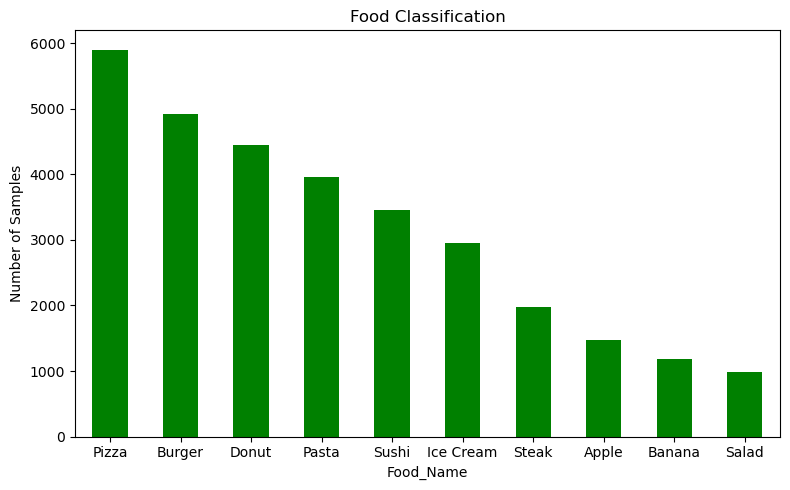

C:\Users\sojay\AppData\Local\Temp\ipykernel_23376\1805692627.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 50), random_state=42))


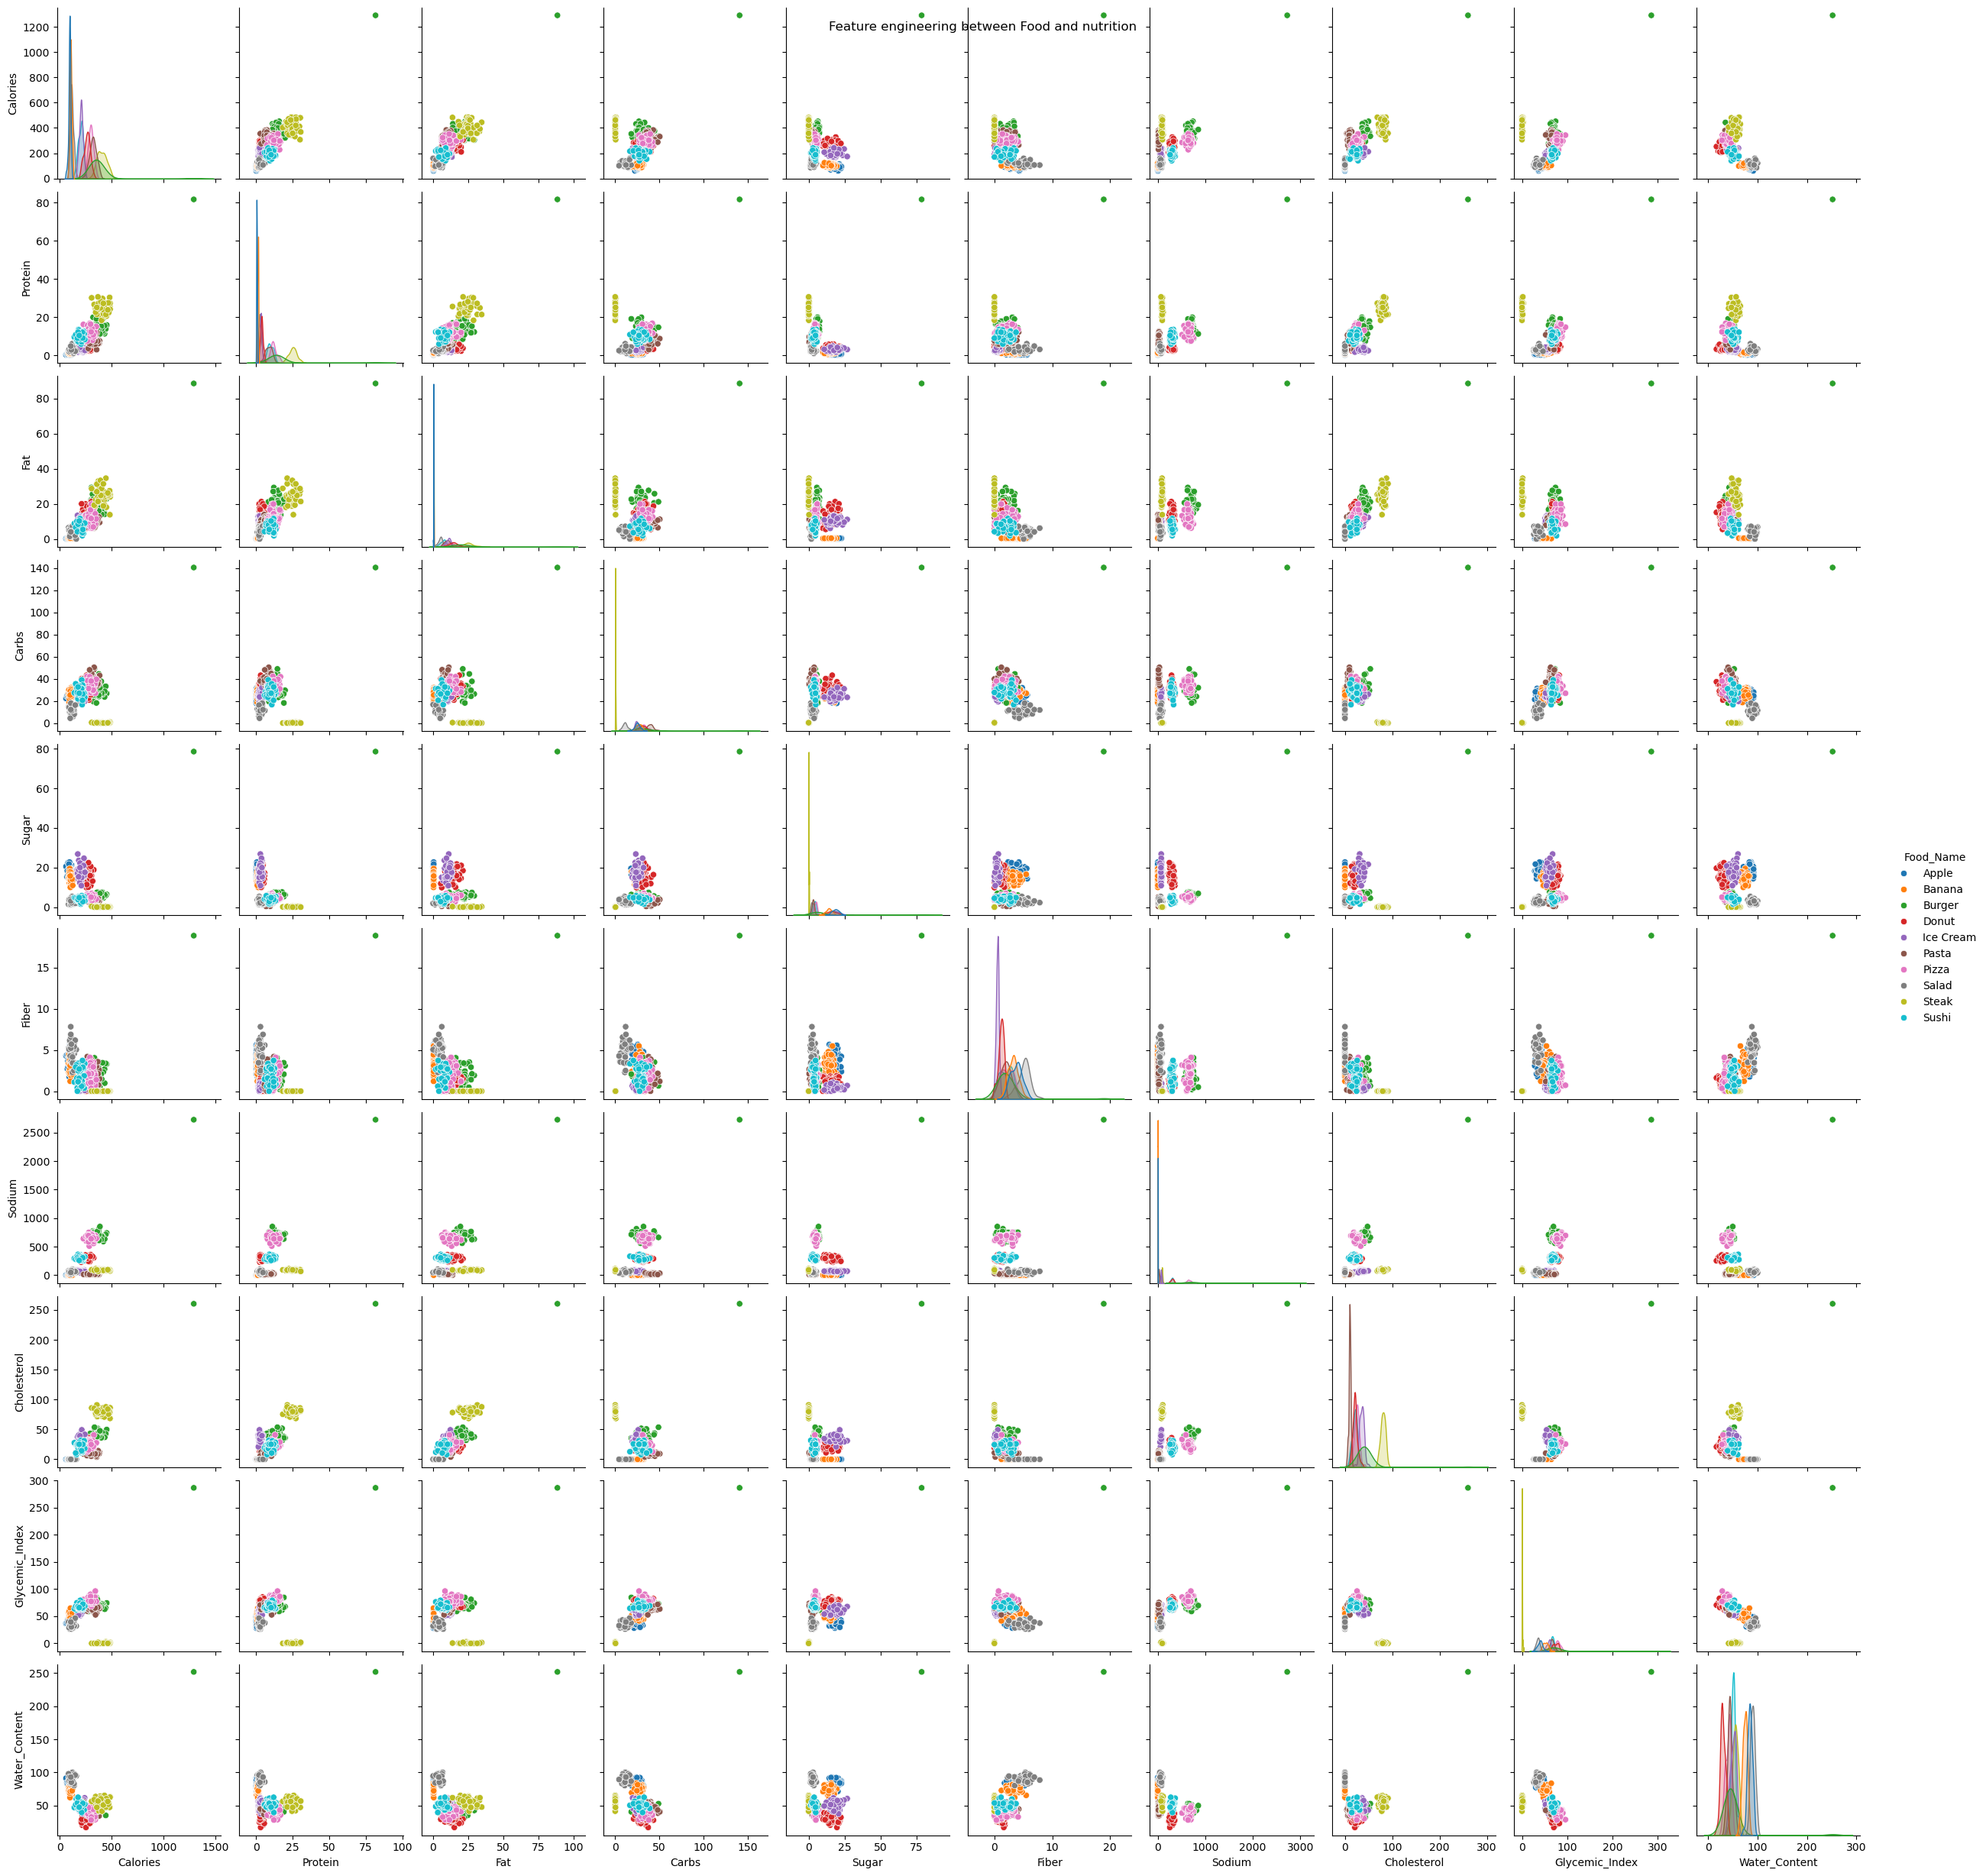

In [5]:
Food_Classification = df['Food_Name'].value_counts()
print("\n Food Name Class Distribution:\n", Food_Classification)
plt.figure(figsize=(8,5))
Food_Classification.plot(kind='bar', color='green')
plt.title('Food Classification')
plt.xlabel('Food_Name')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#box plot
sample_df = (
    df.groupby("Food_Name", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), 50), random_state=42))
)

sns.pairplot(sample_df, vars=Feature, hue="Food_Name")
plt.suptitle("Feature engineering between Food and nutrition")
plt.show()


#Feature Engineering with PCA

 Class Labels Encoded: ['Apple', 'Banana', 'Burger', 'Donut', 'Ice Cream', 'Pasta', 'Pizza', 'Salad', 'Steak', 'Sushi']
{0: 'Apple', 1: 'Banana', 2: 'Burger', 3: 'Donut', 4: 'Ice Cream', 5: 'Pasta', 6: 'Pizza', 7: 'Salad', 8: 'Steak', 9: 'Sushi'}


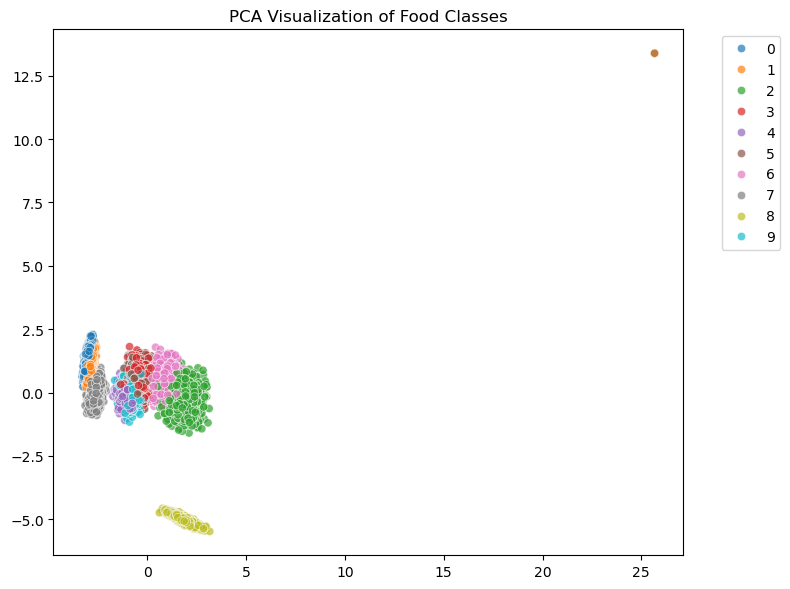

 Explained Variance Ratio: [0.38707349 0.24143738]


In [6]:
label_encoder = LabelEncoder()
df['Food_Name_Label'] = label_encoder.fit_transform(df['Food_Name'])
print(" Class Labels Encoded:", list(label_encoder.classes_))

X = df[Feature]
y = df["Food_Name_Label"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(dict(enumerate(label_encoder.classes_)))

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['Food_Name_Label'],
    palette="tab10",
    alpha=0.7)
plt.title("PCA Visualization of Food Classes")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(" Explained Variance Ratio:", pca.explained_variance_ratio_)

#Inner class variation

In [7]:
sample_df = (
    df.groupby("Food_Name", group_keys=False)
      .apply(lambda x: x.sample(5, random_state=42))
)

sample_df

C:\Users\sojay\AppData\Local\Temp\ipykernel_23376\1066598102.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(5, random_state=42))


,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name,Food_Name_Label
18920,88.831447,0.669344,0.398466,27.351470,20.585923,4.569030,2.131523,0.000000,46.051619,83.131396,153.699792,lunch,baked,True,True,Apple,0
3795,93.549926,0.936182,0.150709,24.465138,16.105486,2.413314,1.884108,0.000000,34.943445,89.185963,162.987489,breakfast,fried,True,True,Apple,0
26944,91.157253,0.383083,0.385768,26.279071,18.966745,2.786889,1.032238,0.000000,41.116436,84.919454,156.649271,lunch,grilled,True,True,Apple,0
1485,95.100212,0.362261,0.268903,26.207549,20.338877,3.887874,0.086660,0.000000,44.482498,71.297868,161.874272,dinner,grilled,True,True,Apple,0
4602,101.507151,0.754311,0.385415,26.483842,21.910286,2.691525,1.315538,0.000000,38.493060,88.429502,138.848965,breakfast,baked,True,True,Apple,0
9236,97.010961,1.338769,0.473392,30.501184,19.450946,2.111370,1.703918,0.000000,54.851319,74.842735,117.837979,snack,baked,True,True,Banana,1
25536,119.988986,1.250650,0.407044,26.864774,16.552074,5.485819,0.000000,0.000000,54.121872,65.271463,113.711249,breakfast,grilled,True,True,Banana,1
28719,113.736062,0.838404,0.248831,23.435669,13.288985,3.403860,0.399517,0.000000,49.812446,77.192172,118.570040,breakfast,fried,True,True,Banana,1
2363,105.863386,1.806631,0.399530,27.445043,13.241941,3.395617,0.584554,0.000000,48.782175,71.550170,131.682415,lunch,raw,True,True,Banana,1
26247,107.149662,1.409277,0.417249,23.921019,17.267492,3.808535,0.876523,0.000000,59.819238,78.814908,124.612129,snack,raw,True,True,Banana,1


# Statistical ananlysis

In [8]:
print(f"Statistical analysis\n {df.describe()}")
print(df.dtypes)

Statistical analysis
            Calories       Protein           Fat         Carbs         Sugar  \
count  31260.000000  31260.000000  31260.000000  31260.000000  31260.000000   
mean     271.264635      9.373595     12.318521     28.711059      8.398251   
std      101.464986      7.324500      7.685144     11.612947      7.331201   
min       60.786204      0.000000      0.000000      0.000000      0.000000   
25%      210.226038      3.853169      8.237307     25.086253      3.735358   
50%      281.551993      9.077022     11.563735     29.662508      5.491571   
75%      329.557312     12.665367     15.783221     34.601958     14.375863   
max     1289.956763     81.761772     88.619611    140.585537     78.548162   

              Fiber        Sodium   Cholesterol  Glycemic_Index  \
count  31260.000000  31260.000000  31260.000000    31260.000000   
mean       1.868721    330.420394     26.380091       63.752078   
std        1.603749    300.206402     22.608649       23.310749  

#Outliers

In [9]:
iqr_values = df[Feature].apply(iqr)
print(f"Quartile Range \n {iqr_values}")
outlier_summary = {}

for col in Feature:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    iqr_range = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * iqr_range) | (df[col] > Q3 + 1.5 * iqr_range)]
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(
    outlier_summary,
    orient='index',
    columns=['Outlier_Count']
)

outlier_df
outlier_df['Outlier_%'] = (outlier_df['Outlier_Count'] / len(df)) * 100
outlier_df.sort_values(by='Outlier_%', ascending=False)


Quartile Range 
 Calories          119.331274
Protein             8.812198
Fat                 7.545914
Carbs               9.515705
Sugar              10.640504
Fiber               1.921696
Sodium            567.727096
Cholesterol        22.348507
Glycemic_Index     15.448671
Water_Content      13.369047
dtype: float64


,Outlier_Count,Outlier_%
Water_Content,3315,10.604607
Glycemic_Index,3094,9.897633
Carbs,2704,8.650032
Cholesterol,2042,6.532310
Protein,845,2.703135
Fat,784,2.507997
Fiber,468,1.497121
Calories,94,0.300704
Sugar,84,0.268714
Sodium,84,0.268714


#Model training and prediction


 Training: Logistic Regression


 Accuracy: 0.9923
              precision    recall  f1-score   support

       Apple       1.00      0.99      0.99       313
      Banana       0.99      0.99      0.99       233
      Burger       0.97      0.98      0.98      1027
       Donut       1.00      1.00      1.00       898
   Ice Cream       1.00      1.00      1.00       593
       Pasta       1.00      1.00      1.00       769
       Pizza       0.99      0.99      0.99      1161
       Salad       1.00      0.99      1.00       187
       Steak       1.00      1.00      1.00       404
       Sushi       1.00      1.00      1.00       667

    accuracy                           0.99      6252
   macro avg       0.99      0.99      0.99      6252
weighted avg       0.99      0.99      0.99      6252


 Training: Decision Tree
 Accuracy: 0.9859
              precision    recall  f1-score   support

       Apple       0.99      0.98      0.99       313
      Banana       0.99      0.99      0.99       233
      Burger    

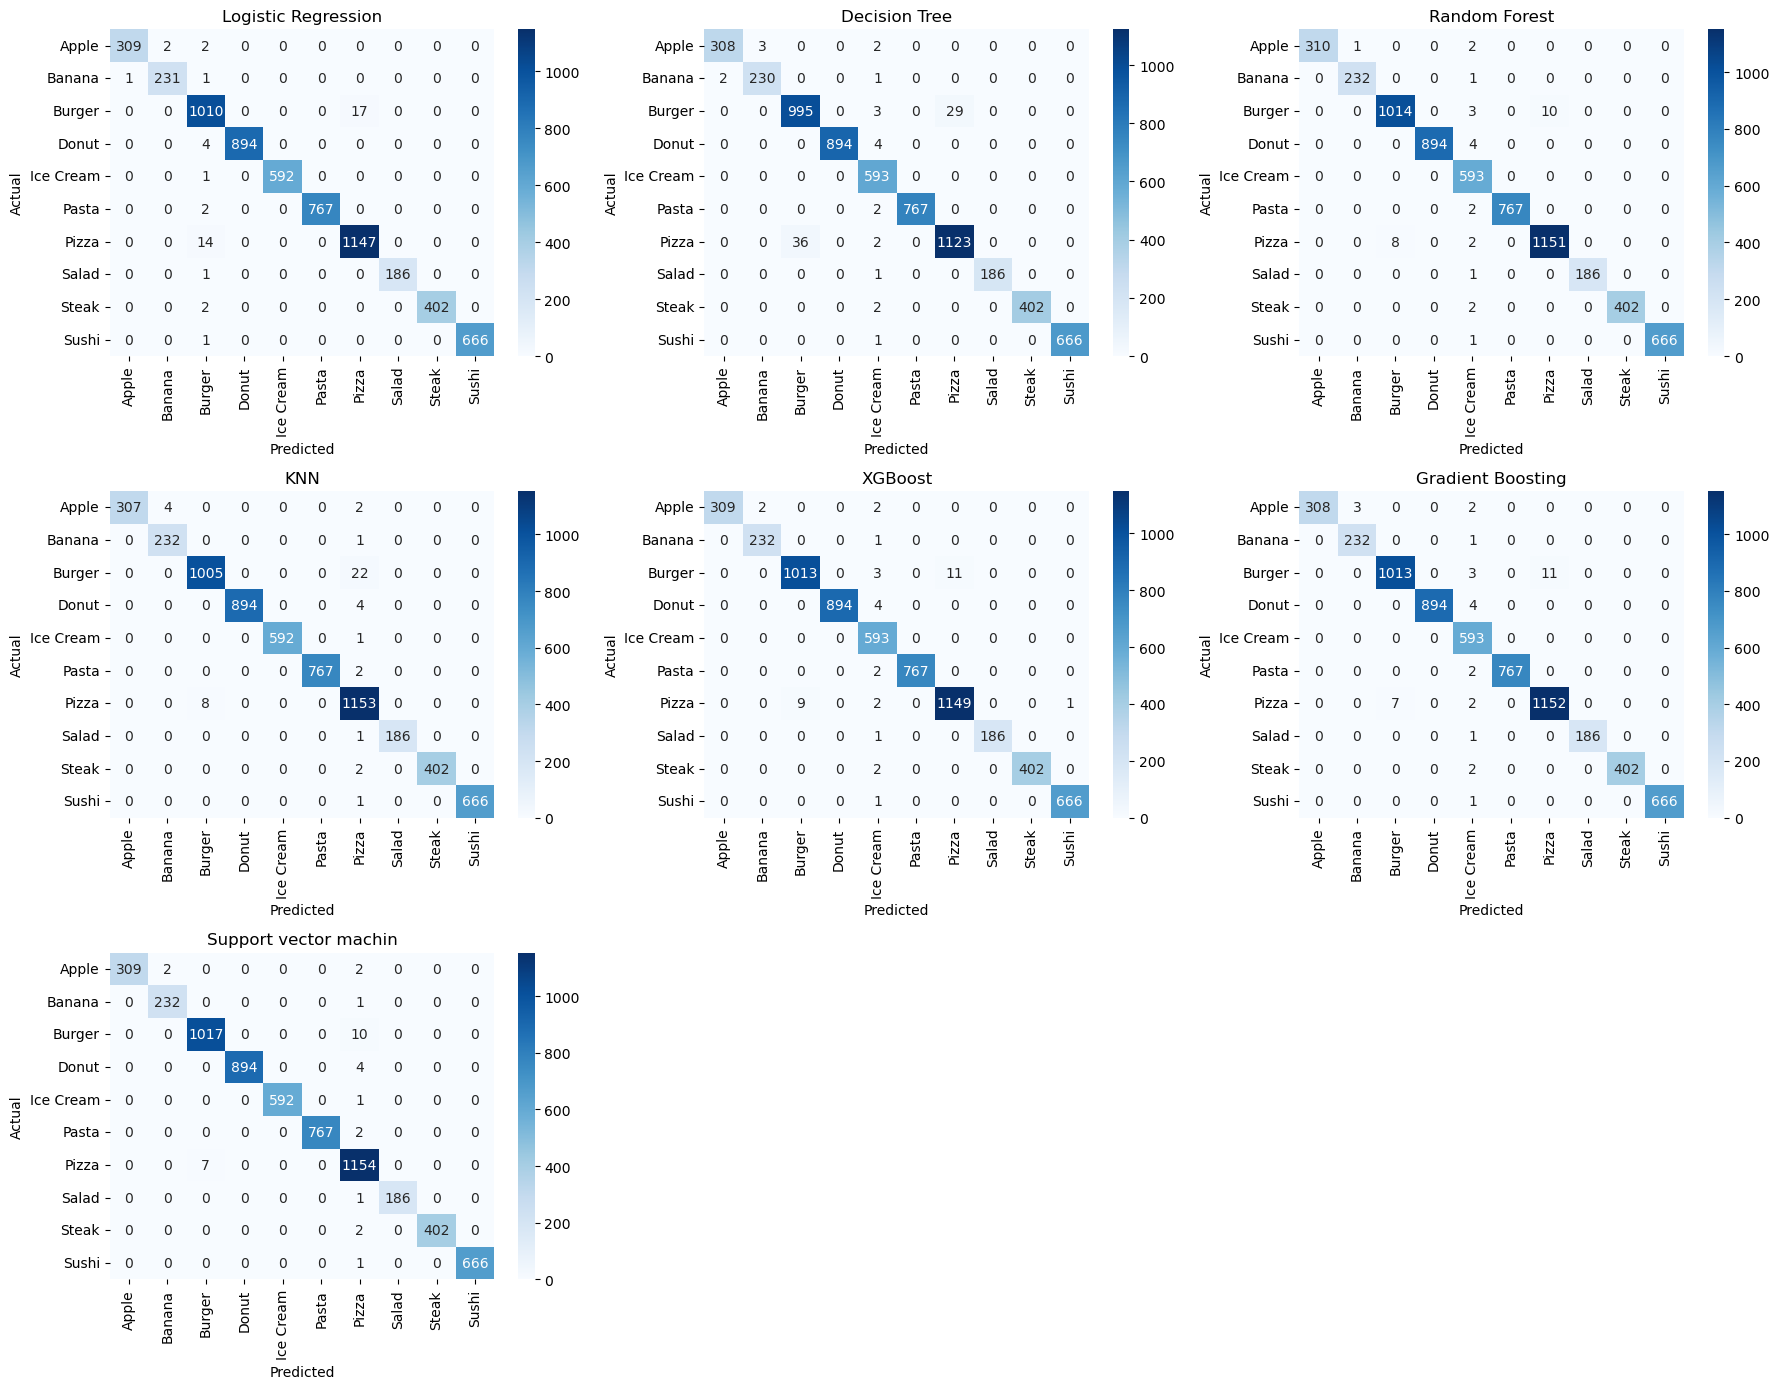

In [10]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support vector machin": SVC(kernel="rbf", probability=True, C=3, gamma=0.025)

}

#Train and Evaluate Models
results = {}

for name, model in models.items():
    print(f"\n Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f" Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    results[name] = {
        "model": model,
        "accuracy": acc,
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

#Visualize Confusion Matrices
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (name, result) in enumerate(results.items()):
    sns.heatmap(result["confusion_matrix"], annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()